In [10]:
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt

### Preliminary investigation into magnitudes for AI detection probabilities ###

This notebook conudcts exploratory data analysis on AI text detection on state house candidates and mayoral candidates in 2025. Then, we measure magnitude using the first formulation (mean detection probability): 

$$
M_{c,t}^{\text{prob}} = \frac{\sum_{d_i \in D_{c,t}} w_i \cdot f(d_i)}{\sum_{d_i \in D_{c,t}} w_i}
$$

Where, for a given candidate $c$ in election cycle $t$, let $D_{c,t} = \{d_1, d_2, \dots, d_n\}$ denote the set of content units (e.g., web pages, emails, social media posts) produced by the campaign. Each content unit $d_i$ has token length $w_i$ and is scored by a detection function $f(d_i) \in [0,1]$, representing the estimated probability that $d_i$ was generated by a large language model.

Note that, importantly, the magnitude equation is per-candidate. Meaning that the formula aggregates AI detection across all text samples of a given candidate. The output of this first formula is the aggregate AI detection probability across a candidate. A score of 0.4, for example, would mean that across all text samples of a candidate, they are classified as "lightly AI generated" as a whole.

We then apply a threshold classification to the formula, creating a second formula for AI detection probability that is the percentage of content from a given candidate that is above an AI generated threshold. This formula is described in the "Magnitude, classification threshold" section below. 

We analyze all candidate data from US house 2025 candidates: 150 candidates for mayor in 2025, and 150 candidates for state house seats. After remove sampled text that is empty (due to inability to scrape website / missing website) we analyze 59 text samples from mayoral candidates and 93 text samples from state house candidates.


In [11]:
#load in pangram results
state_house_2025 = pd.read_csv('/Users/agueorg/Desktop/WeberLab/anna-RA/pangram-text-detection/state-house-2025-first-150-pangram.csv')
mayoral_2025 =  pd.read_csv('/Users/agueorg/Desktop/WeberLab/anna-RA/pangram-text-detection/mayoral-2025-first-150-pangram.csv')
#us_house_2025 = pd.read_csv('/Users/agueorg/Desktop/WeberLab/anna-RA/pangram-text-detection/us-house-2025-all-pangram.csv')

In [48]:
state_house_2025.head(3)

,Unnamed: 0,candidate_name,candidate_id,page_type,sampled_text,AI label,AI assistance score,AI rating confidence,Fraction AI,Fraction AI assistaed,Fraction human,Number AI segments,race_type,len_tokens
0,0,Matt Woods,1,home,Reply HELP for help. DONATE TODAY! $50 $100 $2...,Human Written,0.004833,High,0.0,0.0,1.0,0.0,state house,43
1,1,Matt Woods,1,policy,They deserve our respect and our support. Shar...,Human Written,0.044889,High,0.0,0.0,1.0,0.0,state house,27
2,2,Matt Woods,1,policy,Ive also seen that a pro-business economic env...,Human Written,0.036023,High,0.0,0.0,1.0,0.0,state house,40


An important piece of the magnitude formula is the token length of sampled text. Because Pangram does not have an explicit tokenize function (but rather that occurs behind the scenes) we use a common tokenizer package from nltk (word_tokenize). 

In [20]:
#add a column in each table that is the token length of each sample
state_house_2025['len_tokens'] = state_house_2025['sampled_text'].apply(lambda x: len(nltk.word_tokenize(str(x))))
mayoral_2025['len_tokens'] = mayoral_2025['sampled_text'].apply(lambda x: len(nltk.word_tokenize(str(x))))
#us_house_2025['len_tokens'] = us_house_2025['sampled_text'].apply(lambda x: len(nltk.word_tokenize(str(x))))

In [22]:
#drop rows that are AI assistance score is empty
state_house_2025 = state_house_2025.dropna(subset=['AI assistance score']).reset_index(drop=True)
mayoral_2025 = mayoral_2025.dropna(subset=['AI assistance score']).reset_index(drop=True)
#us_house_2025 = us_house_2025.dropna(subset=['AI assistance score']).reset_index(drop=True)

### Magnitude, mean detection probability ###

The formula for magnitude specifies f(d) where d is the content unit of a campaign (a sample of text) and f(d) is the probability of AI genreated content in d. Pangrams "AI assistance score" output will be used as f(d).

In [29]:
#formula for mean detection probability

def mean_detection_probability(table, candidate):
    #filter for the candidate
    given_rows = table[table['candidate_name'] == candidate]
    ai_assistance_scores= given_rows['AI assistance score']
    token_lengths = given_rows['len_tokens']

    numerator = sum(token_lengths * ai_assistance_scores)
    denom = sum(token_lengths)
    m_prob = numerator / denom
    
    return m_prob

**Visualization of AI detection probability across the mayoral text samples using bar graph:**

In [31]:
mayoral_2025_candidates = mayoral_2025['candidate_name'].unique()
ai_mayoral_scores = []

for candidate in mayoral_2025_candidates:
    m_prob = mean_detection_probability(mayoral_2025, candidate)
    ai_mayoral_scores.append(m_prob)

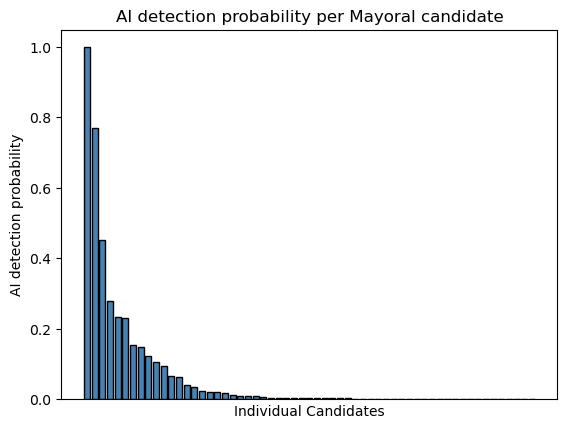

In [76]:
plt.bar(mayoral_2025_candidates, sorted(ai_mayoral_scores, reverse = True), color='steelblue', edgecolor='black')

plt.title('AI detection probability per Mayoral candidate')
plt.xlabel('Individual Candidates')
plt.ylabel('AI detection probability')
plt.xticks([])
plt.show()

**Visualization of AI detection probability across the state house candidate text samples using bar graph:**


In [50]:
house_2025_candidates = state_house_2025['candidate_name'].unique()
ai_house_scores = []

for candidate in house_2025_candidates:
    m_prob_house = mean_detection_probability(state_house_2025, candidate)
    ai_house_scores.append(m_prob_house)

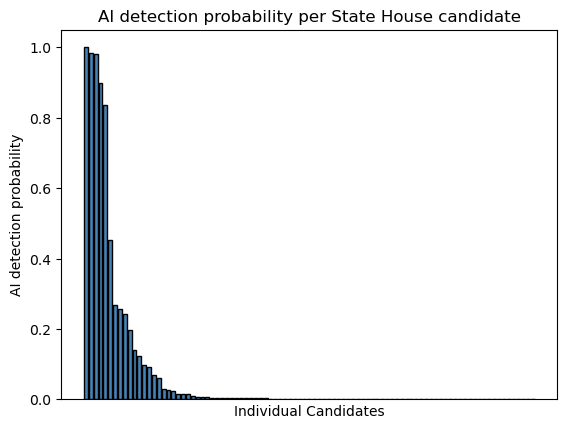

In [74]:
plt.bar(house_2025_candidates, sorted(ai_house_scores, reverse=True), color='steelblue', edgecolor='black')

plt.title('AI detection probability per State House candidate')
plt.xlabel('Individual Candidates')
plt.ylabel('AI detection probability')
plt.xticks([])
plt.show()

**Visualization of frequency of AI detection probabilities across mayoral and state house candidates**

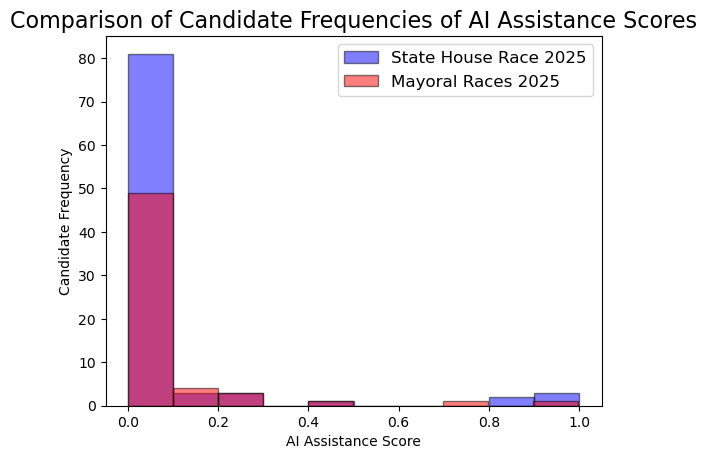

In [78]:
plt.hist(ai_house_scores, bins=10, alpha=0.5, color='blue', edgecolor='black', label='State House Race 2025')
plt.hist(ai_mayoral_scores, bins=10, alpha=0.5, color='red', edgecolor='black', label='Mayoral Races 2025')

plt.rcParams.update({
    'font.size': 14,          # base font size
    'axes.titlesize': 16,     # title
    'axes.labelsize': 15,     # x and y labels
    'xtick.labelsize': 12,    # x tick labels
    'ytick.labelsize': 12,    # y tick labels
    'legend.fontsize': 12,    # legend
})

plt.title('Comparison of Candidate Frequencies of AI Assistance Scores')
plt.xlabel('AI Assistance Score')
plt.ylabel('Candidate Frequency')
plt.legend()
plt.savefig('ai_assistance_by_races.svg')
plt.show()

In [80]:
#percentage of candidates above a threshold value 
#isnt this just formula #2 though?
total_mayoral_above_3= 0
for score in ai_mayoral_scores:
    if score >= 0.3:
        total_mayoral_above_3 += 1

total_house_above_3= 0
for score in ai_house_scores:
    if score >= 0.3:
        total_house_above_3 += 1     

In [396]:
total_mayoral_above_3 / len(ai_mayoral_scores)

0.05084745762711865

In [398]:
total_house_above_3 / len(ai_house_scores)

0.06451612903225806

### Magnitude, classification threshold ###

We then apply a second magnitude formula with a classification threshold $\tau$, the length-weighted proportion of content classified as AI-generated:

$$
M_{c,t}^{\tau} = \frac{\sum_{d_i \in D_{c,t}} w_i \cdot \mathbb{1}[f(d_i) \geq \tau]}{\sum_{d_i \in D_{c,t}} w_i}
$$

where $\mathbb{1}[\cdot]$ is the indicator function. The continuous measure $M_{c,t}^{\text{prob}}$ captures gradations in detection confidence without dependence on a threshold choice, while $M_{c,t}^{\tau}$ provides a more interpretable proportion suitable for policy-relevant reporting. Because results may be sensitive to the choice of $\tau$, we report $M_{c,t}^{\tau}$ at multiple thresholds ($\tau \in \{0.5, 0.7, 0.9\}$) and present sensitivity curves showing how aggregate estimates vary across the full range of $\tau$.


In [84]:
#second formula with classification threshold

def with_classification_threshold(table, candidate, threshold):
    #filter for the candidate
    given_rows = table[table['candidate_name'] == candidate]
    ai_assistance_scores= given_rows['AI assistance score']
    threshold_outputs = []
    
    for i in ai_assistance_scores:
        if i >= threshold:
            threshold_outputs.append(1)
        else:
            threshold_outputs.append(0)
    
    token_lengths = given_rows['len_tokens']

    numerator = sum(token_lengths * threshold_outputs) #now either multiply by one or zero
    denom = sum(token_lengths)
    m_prob = numerator / denom
    
    return m_prob

The output of this second formula is the percentage of content for a candidate that is above a certain threshold. For example, an output of 0.1 with threshold = 0.3 means that "10% of this candidates content has been identified to be lightly or fully AI generated"

In [86]:
scores_classification_house = []

for candidate in house_2025_candidates:
    m_prob_threshold_house = with_classification_threshold(state_house_2025, candidate, 0.3)
    scores_classification_house.append(m_prob_threshold_house)

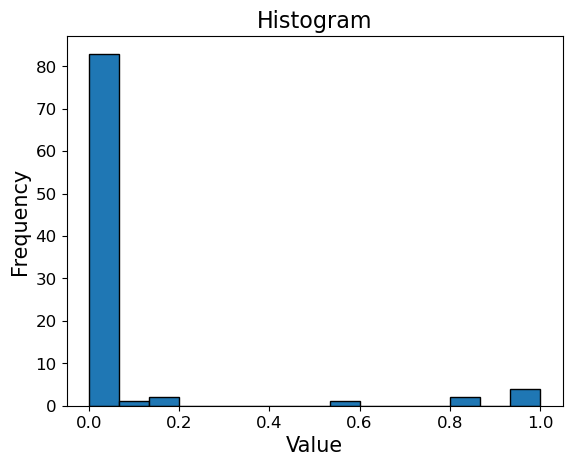

In [88]:
#this is the proportion of content of a given candidate that is above threshold 0.3 (lightly AI generated)
plt.hist(scores_classification_house, bins=15, edgecolor='black')
plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [92]:
#how many candidates have non-zero percentage of content that is above AI generated threshold 0.3
counting = 0
for i in scores_classification_house:
    if i > 0.1:
        counting += 1

counting / len(house_2025_candidates) #9.6% of house candidates have at least 10% AI generated content 

0.0967741935483871

In [53]:
combined_df = pd.concat([state_house_2025, mayoral_2025, us_house_2025], ignore_index=True)

In [71]:
#percentage of not finding a home page
home_pages = combined_df[combined_df["page_type"] == "home"]
len(home_pages[home_pages["sampled_text"] == "ERROR: could not fetch page"]) / len(home_pages)

0.2883895131086142

## Weighting page type by token lengths ##

We then explore the AI detection probability, where we group by page type instead of candidate.

In [90]:
#formula for mean detection probability (first formula) but grouping by page type

def mean_detection_probability_page_type(table, page):
    #filter for the candidate
    given_rows = table[table['page_type'] == page]
    ai_assistance_scores= given_rows['AI assistance score']
    token_lengths = given_rows['len_tokens']

    numerator = sum(token_lengths * ai_assistance_scores)
    denom = sum(token_lengths)
    m_prob = numerator / denom
    
    return m_prob

In [272]:
#save data
columns_fig_page_type = ['race', 'page type', 'AI assistance']
df_page_type_fig = pd.DataFrame(columns=columns_fig_page_type)
race = []
page_type = []
ai_assistance = []

In [274]:
house_2025_page_types = state_house_2025['page_type'].unique()

for page in house_2025_page_types:
    race.append('state house')
    page_type.append(page)
    m_prob_house = mean_detection_probability_page_type(state_house_2025, page)
    ai_assistance.append(m_prob_house)

In [276]:
mayoral_2025_page_types = mayoral_2025['page_type'].unique()

for page_mayor in mayoral_2025_page_types:
    race.append('mayoral')
    page_type.append(page_mayor)
    m_prob_mayor = mean_detection_probability_page_type(mayoral_2025, page_mayor)
    ai_assistance.append(m_prob_mayor)

In [284]:
df_page_type_fig['race'] = race
df_page_type_fig['page type'] = page_type
df_page_type_fig['AI assistance'] = ai_assistance

In [286]:
df_page_type_fig

,race,page type,AI assistance
0,state house,home,0.090847
1,state house,policy,0.175464
2,state house,about,0.053625
3,mayoral,home,0.106682
4,mayoral,policy,0.223345
5,mayoral,about,0.052691


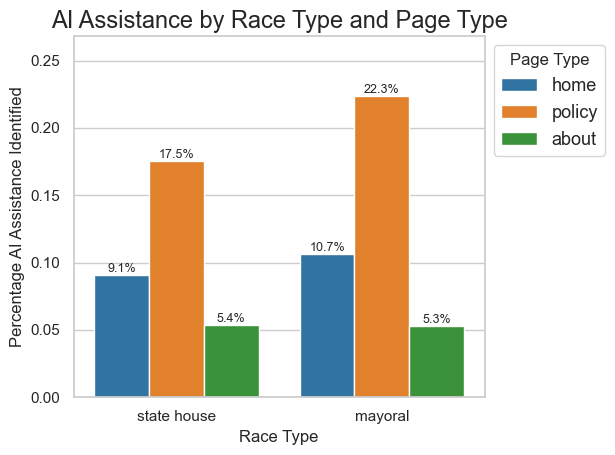

In [442]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("notebook")  # increases font sizes globally

ax = sns.barplot(data=df_page_type_fig, x='race', y='AI assistance', hue='page type')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1%}', 
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.rcParams.update({
    'font.size': 15,          # base font size
    'axes.titlesize': 17,     # title
    'axes.labelsize': 16,     # x and y labels
    'xtick.labelsize': 13,    # x tick labels
    'ytick.labelsize': 13,    # y tick labels
    'legend.fontsize': 13,    # legend
})


plt.title('AI Assistance by Race Type and Page Type')
plt.ylim(0, df_page_type_fig['AI assistance'].max() * 1.2)  # 20% padding above max
plt.xlabel('Race Type')
plt.ylabel('Percentage AI Assistance Identified')
plt.legend(title='Page Type', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.savefig('ai_assistance_by_page_type.svg')
plt.show()



### OLD ANALYSIS; Exploratory of the amount of pages with AI detected ###

This analysis is no longer relevant as it does not use our formulas for magnitude that also takes into account token length

In [73]:
#amounts of page type
print("Percentage of home pages:", len(home_pages) / len(combined_df))
print("Percentage of policy pages:", len(combined_df[combined_df["page_type"] == "policy"]) / len(combined_df))
print("Percentage of amount pages:", len(combined_df[combined_df["page_type"] == "about"]) / len(combined_df))

Percentage of home pages: 0.644927536231884
Percentage of policy pages: 0.1497584541062802
Percentage of amount pages: 0.20531400966183574


In [97]:
#total empty samples
len(combined_df[combined_df["sampled_text"] == "ERROR: could not fetch page"]) / len(combined_df)

0.1859903381642512

In [31]:
#percentage of mayoral race for each website page that is above 30% AI assistance
#choose 0.3 because 0.3 is considered "lightly AI assisted" -- will do deeper dive into these distinctions just wanted to do EDA first
home_mayoral = mayoral_2025[mayoral_2025["page_type"] == "home"]
policy_mayoral = mayoral_2025[mayoral_2025["page_type"] == "policy"]
about_mayoral = mayoral_2025[mayoral_2025["page_type"] == "about"]

print('AI assistance percentage home page mayoral', len(home_mayoral[home_mayoral["AI assistance score"] > 0.3]) / len(home_mayoral))
print('AI assistance percentage policy page mayoral', len(policy_mayoral[policy_mayoral["AI assistance score"] > 0.3]) / len(policy_mayoral))
print('AI assistance percentage about page mayoral', len(about_mayoral[about_mayoral["AI assistance score"] > 0.3]) / len(about_mayoral))

AI assistance percentage home page mayoral 0.03669724770642202
AI assistance percentage policy page mayoral 0.05
AI assistance percentage about page mayoral 0.04


In [33]:
home_state_house = state_house_2025[state_house_2025["page_type"] == "home"]
policy_state_house = state_house_2025[state_house_2025["page_type"] == "policy"]
about_state_house = state_house_2025[state_house_2025["page_type"] == "about"]

print('AI assistance percentage home page state house', len(home_state_house[home_state_house["AI assistance score"] > 0.3]) / len(home_state_house))
print('AI assistance percentage policy page state house', len(policy_state_house[policy_state_house["AI assistance score"] > 0.3]) / len(policy_state_house))
print('AI assistance percentage about page state house', len(about_state_house[about_state_house["AI assistance score"] > 0.3]) / len(about_state_house))

AI assistance percentage home page state house 0.047244094488188976
AI assistance percentage policy page state house 0.13157894736842105
AI assistance percentage about page state house 0.061224489795918366


In [41]:
home_us_house = us_house_2025[us_house_2025["page_type"] == "home"]
policy_us_house = us_house_2025[us_house_2025["page_type"] == "policy"]
about_us_house = us_house_2025[us_house_2025["page_type"] == "about"]

print('AI assistance percentage home page US house', len(home_us_house[home_us_house["AI assistance score"] > 0.3]) / len(home_us_house))
print('AI assistance percentage policy page US house', len(policy_us_house[policy_us_house["AI assistance score"] > 0.3]) / len(policy_us_house))
print('AI assistance percentage about page US house', len(about_us_house[about_us_house["AI assistance score"] > 0.3]) / len(about_us_house))

AI assistance percentage home page US house 0.0967741935483871
AI assistance percentage policy page US house 0.25
AI assistance percentage about page US house 0.0


In [91]:

# --- Sample Data ---
# Percentage of values > 0.3 for each (group, category) combination
# Replace these with your actual computed percentages

data = {
    'home':   [3.7, 9.7, 4.7],  # mayoral, US house, state house
    'policy': [5.0, 25.0 ,13.2],
    'about':  [4.0, 0.0, 6.1]
}

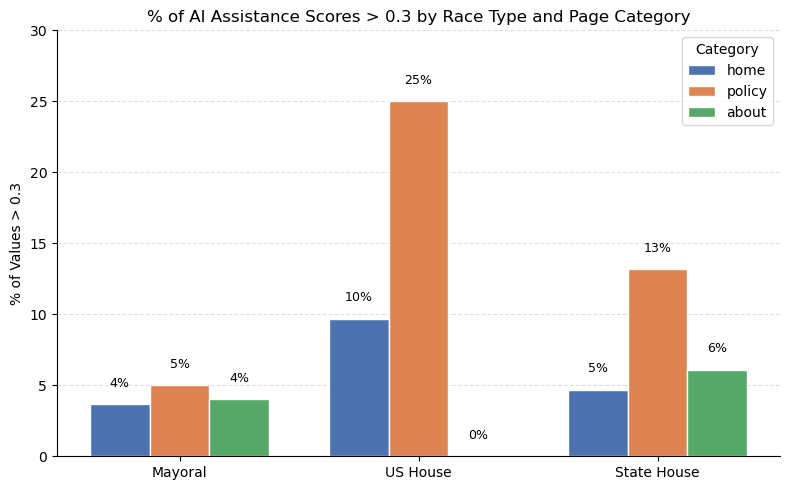

In [93]:


groups = ['Mayoral', 'US House', 'State House']
colors = ['#4C72B0', '#DD8452', '#55A868']

x = np.arange(len(groups))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

for i, (cat, color) in enumerate(zip(data, colors)):
    offset = (i - 1) * bar_width
    bars = ax.bar(x + offset, data[cat], width=bar_width, label=cat, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('% of Values > 0.3')
ax.set_ylim(0, 30)
ax.set_title('% of AI Assistance Scores > 0.3 by Race Type and Page Category')
ax.legend(title='Category')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

home 0.10668234770076675
policy 0.22334519041601011
about 0.05269106273895142
